# AI Disclosure Archetypes

> "I identify firm-level AI disclosure archetypes based on the balance between AI claims, operational evidence, risk disclosure, governance detail, and promotional language."

**Design:** Build 9 interpretable dimension scores from existing features + a new section-location feature from chunks. Cluster on those scores. Read the cluster solution post-hoc and label archetypes — no predefined structure.

| # | Dimension | What it captures |
|---|---|---|
| D1 | **AI Intensity** | Volume of AI discussion |
| D2 | **Operational Embeddedness** | Evidence of actual AI use in products/processes |
| D3 | **Technical Specificity** | Concrete technical language vs vague claims |
| D4 | **Quantification** | Numbers, KPIs, dollars attached to AI claims |
| D5 | **Governance Maturity** | Formal AI governance structures |
| D6 | **Risk Disclosure Depth** | Breadth and specificity of risk disclosure |
| D7 | **Promotional Tone** | Buzzword density — transformation/revolution language |
| D8 | **Competitive/Defensive Exposure** | AI as external threat, not internal capability |
| D9 | **Section Location** | Business/MD&A (substantive) vs Risk Factors (boilerplate) |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import hdbscan
import umap

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
DATA = Path('../data')

## 0. Load data

In [2]:
df = pd.read_parquet(DATA / 'processed/features/firm_year_features.parquet')
print(f'firm_year_features: {df.shape}')

META = ['ticker', 'year', 'industry_group', 'post_sec_2024', 'post_deepseek']
meta = df[META].copy()

firm_year_features: (658, 354)


## 1. Section-location feature (D9) — computed from chunks

Captures *where* AI is discussed. Business/MD&A = substantive; Risk Factors only = boilerplate compliance filing.

In [3]:
# Section features are already correctly aggregated in 10_build_features.py
print("Section features already present in firm_year_features.parquet:")
print([c for c in df.columns if c.startswith("sec_pct_")])


Section features already present in firm_year_features.parquet:
['sec_pct_business', 'sec_pct_mda', 'sec_pct_other', 'sec_pct_risk_factors']


## 2. Build dimension scores

Each dimension is an average of its constituent features, then rescaled 0–1 across the sample.

In [4]:
from scipy.stats import mstats

def make_dim(label, *cols, log=False):
    avail = [df[c] for c in cols if c in df.columns]
    if not avail:
        print(f'  {label}: NO features found')
        return pd.Series(0.0, index=df.index)
    raw = pd.concat(avail, axis=1).mean(axis=1)
    if log:
        raw = np.log1p(raw)
    # Winsorize at 1st/99th percentile before standardization — prevents outlier firms
    # from stretching the scale and making the dimension uninterpretable across years.
    winsorized = pd.Series(
        mstats.winsorize(raw.values, limits=[0.01, 0.01]),
        index=df.index
    )
    print(f'  {label}: {len(avail)}/{len(cols)} cols  mean={winsorized.mean():.3f}')
    return winsorized

print('Dimension scores:')
dims = pd.DataFrame({
    'd1_intensity': make_dim('D1 Intensity',
        'ai_mentions_count', 'share_word_ai',
        'share_word_artificial_intelligence', 'share_word_machine_learning', log=True),

    'd2_operational': make_dim('D2 Operational',
        'share_deployment_verb', 'share_specific_product',
        'share_customer_facing', 'share_product_integration',
        'share_internal_productivity', 'share_safety_critical',
        'share_word_automate_tasks', 'share_word_customer_facing',
        'share_word_back_office', 'share_word_internal_operations'),

    'd3_technical': make_dim('D3 Technical',
        'share_model_training', 'share_compute_infra',
        'share_proprietary_data', 'share_academic_research',
        'share_gen_ai_mention', 'share_classical_ml_mention',
        'share_word_gpu', 'share_word_gpus',
        'share_word_a100', 'share_word_h100', 'share_word_h200',
        'share_word_fine_tuned', 'share_word_fine_tuning',
        'share_word_foundation_model', 'share_word_foundation_models',
        'share_word_inference', 'share_word_embedding', 'share_word_embeddings',
        'share_word_dataset', 'share_word_datasets',
        'share_word_llm', 'share_word_llms', 'share_word_deep_learning',
        'share_word_parameter', 'share_word_parameters',
        'share_word_generative_ai', 'share_word_large_language_model',
        'share_word_rag', 'share_word_retrieval_augmented_generation',
        'share_word_cuda', 'share_word_transformer', 'share_word_transformers'),

    'd4_quantification': make_dim('D4 Quantification',
        'share_metric_dollar', 'share_metric_percentage',
        'share_capex_mention', 'share_opex_mention',
        'share_rd_mention', 'share_revenue_impact',
        'share_word_capital_expenditures', 'share_word_r_d',
        'share_word_research_and_development',
        'share_word_productivity', 'share_word_efficiency'),

    'd5_governance': make_dim('D5 Governance',
        'share_board_oversight', 'share_audit_committee',
        'share_ethics_policy', 'share_compliance',
        'share_eu_regulation', 'share_us_regulation',
        'share_word_board_oversight', 'share_word_audit_committee',
        'share_word_responsible_ai', 'share_word_ethical_ai',
        'share_word_gdpr', 'share_word_ccpa',
        'share_word_eu_ai_act', 'share_word_executive_order'),

    'd6_risk': make_dim('D6 Risk',
        'share_risk_factor', 'share_regulatory_risk',
        'share_cyber_privacy_risk', 'share_ethics_bias_risk',
        'share_ip_copyright_risk', 'share_supply_infra_risk',
        'share_labor_displacement_risk',
        'share_word_cybersecurity', 'share_word_breach', 'share_word_breaches',
        'share_word_liability', 'share_word_litigation',
        'share_word_harm', 'share_word_failure', 'share_word_failures',
        'share_word_regulation', 'share_word_regulations'),

    'd7_promotional': make_dim('D7 Promotional',
        'share_word_transformative', 'share_word_transform', 'share_word_transforming',
        'share_word_revolutionize', 'share_word_revolutionizing',
        'share_word_empower', 'share_word_empowering',
        'share_word_seamless', 'share_word_cutting_edge',
        'share_word_breakthrough', 'share_word_groundbreaking',
        'share_word_pioneer', 'share_word_pioneering',
        'share_word_state_of_the_art', 'share_word_world_class',
        'share_word_next_generation', 'share_word_next_gen',
        'share_word_unlock', 'share_word_unlocking', 'share_word_unprecedented',
        'share_word_leader', 'share_word_leadership',
        'share_word_innovation', 'share_word_innovative',
        'share_word_opportunities', 'share_word_enhance', 'share_word_enhancing'),

    'd8_defensive': make_dim('D8 Defensive',
        'share_competitor_mention',
        'share_word_disrupt', 'share_word_disruption',
        'share_word_disruptions', 'share_word_disruptive', 'share_word_disrupting',
        'share_word_threat', 'share_word_threats',
        'share_word_challenge', 'share_word_challenges',
        'share_word_adversely', 'share_word_uncertainty', 'share_word_uncertainties'),

    'd9_risk_section':        make_dim('D9 Risk-section',        'sec_pct_risk_factors'),
    'd9_substantive_section': make_dim('D9 Substantive-section', 'sec_pct_business', 'sec_pct_mda'),
})

print(f'\nDimension matrix: {dims.shape}')


Dimension scores:
  D1 Intensity: 4/4 cols  mean=0.632
  D2 Operational: 10/10 cols  mean=0.049
  D3 Technical: 32/32 cols  mean=0.021
  D4 Quantification: 11/11 cols  mean=0.031
  D5 Governance: 14/14 cols  mean=0.020
  D6 Risk: 17/17 cols  mean=0.179
  D7 Promotional: 27/27 cols  mean=0.050
  D8 Defensive: 13/13 cols  mean=0.129
  D9 Risk-section: 1/1 cols  mean=0.411
  D9 Substantive-section: 2/2 cols  mean=0.143

Dimension matrix: (658, 10)


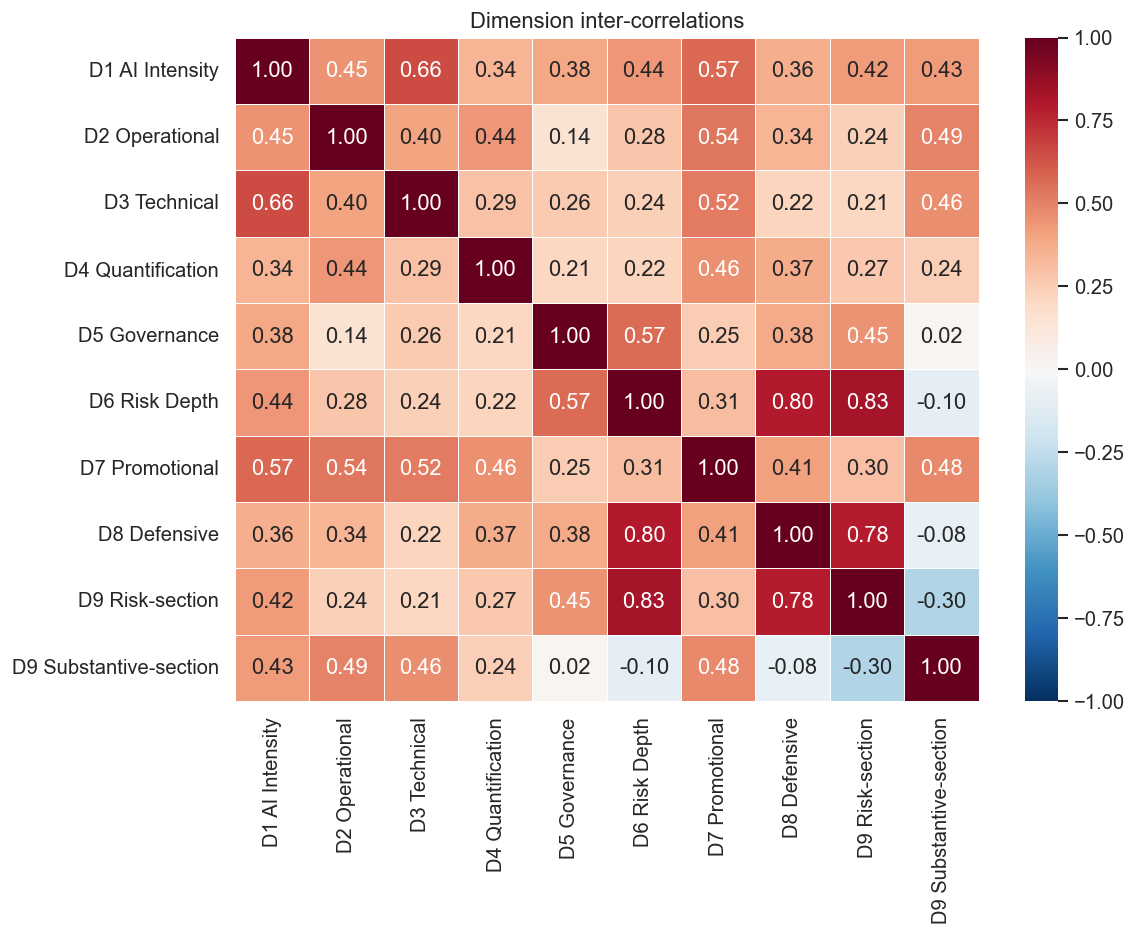

In [5]:
DIM_LABELS = {
    'd1_intensity':           'D1 AI Intensity',
    'd2_operational':         'D2 Operational',
    'd3_technical':           'D3 Technical',
    'd4_quantification':      'D4 Quantification',
    'd5_governance':          'D5 Governance',
    'd6_risk':                'D6 Risk Depth',
    'd7_promotional':         'D7 Promotional',
    'd8_defensive':           'D8 Defensive',
    'd9_risk_section':        'D9 Risk-section',
    'd9_substantive_section': 'D9 Substantive-section',
}

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    dims.rename(columns=DIM_LABELS).corr(),
    annot=True, fmt='.2f', center=0,
    cmap='RdBu_r', linewidths=0.4, ax=ax, vmin=-1, vmax=1
)
ax.set_title('Dimension inter-correlations')
plt.tight_layout()
plt.show()

## 3. Ward hierarchical clustering

Disclosers: 459  |  Non-disclosers: 199
Clustering on 9 dimensions (D1 excluded)


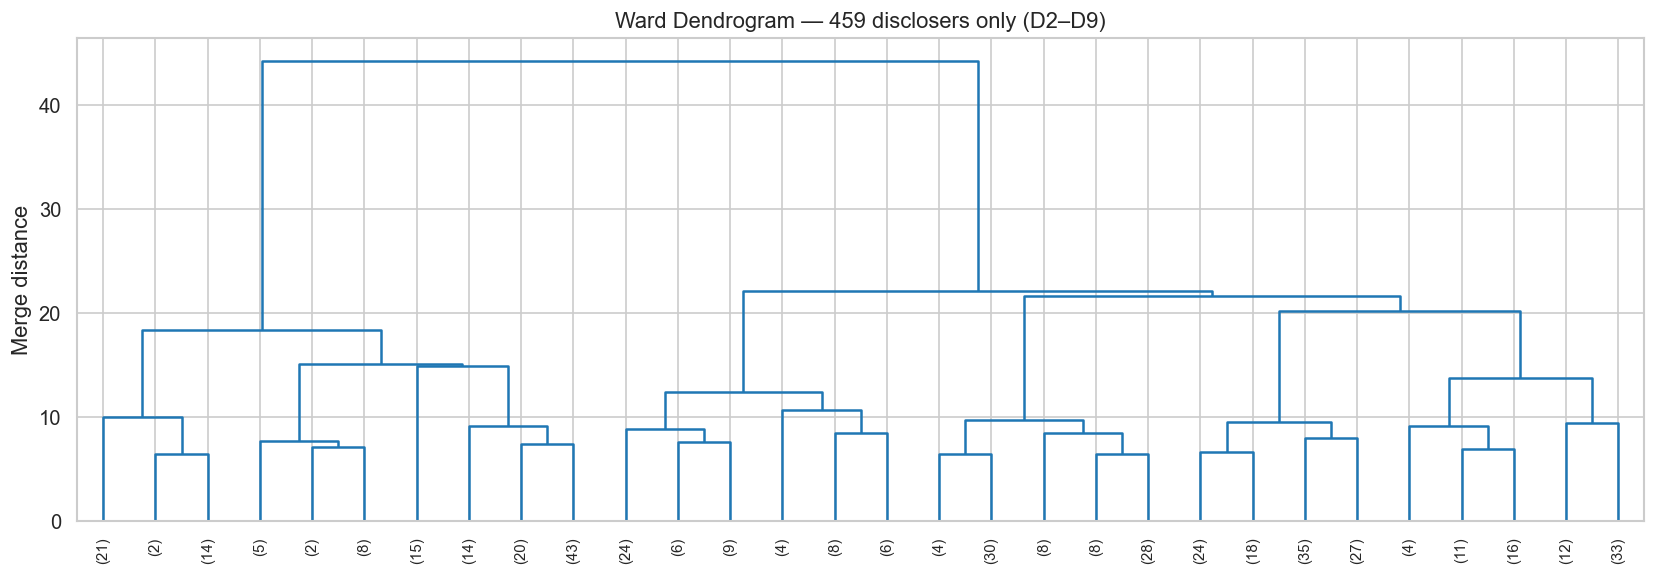

In [6]:
# Non-disclosers (ai_mentions_count == 0) are all-zero vectors.
# Including them inflates the k=3 silhouette by giving Ward one trivially tight cluster.
# They are not a "communication style" — they are an absence.
# Fix: run Ward on the 459 disclosers only, re-attach non-disclosers post-hoc.
disc_mask = df['ai_mentions_count'].values > 0
print(f'Disclosers: {disc_mask.sum()}  |  Non-disclosers: {(~disc_mask).sum()}')

CLUSTER_DIMS = [c for c in dims.columns if c != 'd1_intensity']
print(f'Clustering on {len(CLUSTER_DIMS)} dimensions (D1 excluded)')

X_full = StandardScaler().fit_transform(dims[CLUSTER_DIMS].values)  # all 658 — kept for UMAP
X      = X_full[disc_mask]   # Ward runs on disclosers only

Z = linkage(X, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9, ax=ax, color_threshold=0)
ax.set_title(f'Ward Dendrogram — {disc_mask.sum()} disclosers only (D2–D9)')
ax.set_ylabel('Merge distance')
plt.tight_layout()
plt.show()


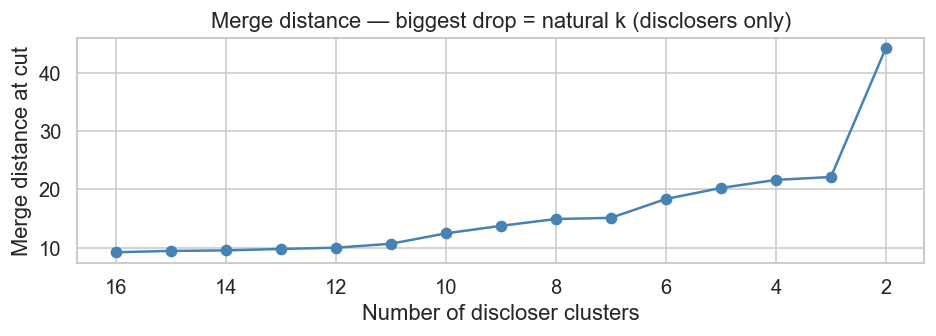

Largest gap at k = 14
k=4  sil=0.1438  CH=89.1  DB=1.813  sizes={np.int32(0): np.int64(144), np.int32(1): np.int64(57), np.int32(2): np.int64(78), np.int32(3): np.int64(180)}
k=5  sil=0.1032  CH=82.8  DB=1.754  sizes={np.int32(0): np.int64(144), np.int32(1): np.int64(57), np.int32(2): np.int64(78), np.int32(3): np.int64(104), np.int32(4): np.int64(76)}
k=6  sil=0.1208  CH=78.6  DB=1.678  sizes={np.int32(0): np.int64(37), np.int32(1): np.int64(107), np.int32(2): np.int64(57), np.int32(3): np.int64(78), np.int32(4): np.int64(104), np.int32(5): np.int64(76)}
k=7  sil=0.1309  CH=73.4  DB=1.613  sizes={np.int32(0): np.int64(37), np.int32(1): np.int64(15), np.int32(2): np.int64(92), np.int32(3): np.int64(57), np.int32(4): np.int64(78), np.int32(5): np.int64(104), np.int32(6): np.int64(76)}

Best k among disclosers (silhouette, floor=4): 4


In [7]:
last_merges = Z[-15:, 2][::-1]
gaps = np.diff(last_merges)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(2, len(last_merges) + 2), last_merges, 'o-', color='steelblue')
ax.set_xlabel('Number of discloser clusters')
ax.set_ylabel('Merge distance at cut')
ax.set_title('Merge distance — biggest drop = natural k (disclosers only)')
ax.invert_xaxis()
plt.tight_layout()
plt.show()

suggested_k = int(np.argmax(gaps)) + 2
print(f'Largest gap at k = {suggested_k}')

# k floor=4 among disclosers. Non-disclosers will be a fixed additional label.
# Target 4-6 meaningful discloser archetypes → 5-7 total clusters.
ward_scores = {}
for k in range(4, 8):
    labels = fcluster(Z, k, criterion='maxclust') - 1
    ward_scores[k] = dict(
        silhouette=silhouette_score(X, labels),
        ch=calinski_harabasz_score(X, labels),
        db=davies_bouldin_score(X, labels),
        labels=labels,
    )
    sizes = dict(zip(*np.unique(labels, return_counts=True)))
    print(f'k={k}  sil={ward_scores[k]["silhouette"]:.4f}  '
          f'CH={ward_scores[k]["ch"]:.1f}  DB={ward_scores[k]["db"]:.3f}  sizes={sizes}')

best_k = max(ward_scores, key=lambda k: ward_scores[k]['silhouette'])
print(f'\nBest k among disclosers (silhouette, floor=4): {best_k}')


In [8]:
K_disc = best_k
disc_labels = ward_scores[K_disc]['labels']   # integer labels for the 459 disclosers

# Assign non-disclosers slot K_disc (one beyond the last discloser cluster)
all_labels = np.full(len(dims), K_disc, dtype=int)
all_labels[disc_mask] = disc_labels

K = K_disc + 1          # total clusters (discloser archetypes + Non-AI Disclosers)
ward_labels = all_labels

result = meta.copy()
result['cluster'] = ward_labels
result['ai_mentions_count'] = df['ai_mentions_count'].values

# --- Auto-name Ward clusters from discloser centroid profiles ---
disc_df = pd.DataFrame(X, columns=CLUSTER_DIMS)
centroid_means = disc_df.assign(cluster=disc_labels).groupby('cluster').mean()
centroid_z     = (centroid_means - disc_df.mean()) / disc_df.std().replace(0, 1)

def name_from_centroid(c):
    cz      = centroid_z.loc[c]
    d9sub   = 'd9_substantive_section'
    top_dim = cz.drop([d for d in CLUSTER_DIMS if 'd9' in d], errors='ignore').idxmax()
    # Governance-focused: D5 leads the centroid or is the globally highest D5 among clusters
    if top_dim == 'd5_governance' or (
        cz['d5_governance'] > 0.3
        and cz['d5_governance'] == centroid_z['d5_governance'].max()
    ):
        return 'Governance & Compliance-Focused'
    # Full-Stack Pioneers: above-average intensity + technical/operational + substantive section
    if (cz.get('d1_intensity', 0) > 0.2
            and (d9sub in cz.index and cz[d9sub] > 0)
            and (cz.get('d3_technical', 0) > 0 or cz.get('d2_operational', 0) > 0)):
        return 'Full-Stack AI Pioneers'
    # Promotional Claimants: D7 leads and D9-substantive is low (boilerplate risk + hype)
    if (top_dim == 'd7_promotional'
            or (cz.get('d7_promotional', 0) > 0.3
                and (d9sub not in cz.index or cz[d9sub] <= 0))):
        return 'Promotional AI Claimants'
    # Operational Adopters: AI in substantive sections, moderate profile
    if d9sub in cz.index and cz[d9sub] > 0:
        return 'Operational Application Adopters'
    # Default: AI is primarily boilerplate Risk Factors language
    return 'Boilerplate Risk-Warners'

auto_names = {c: name_from_centroid(c) for c in range(K_disc)}
auto_names[K_disc] = 'Non-AI Disclosers'

print(f'\nAuto-named {K} clusters ({K_disc} discloser archetypes + 1 Non-AI Disclosers):')
for c, name in auto_names.items():
    n = int((ward_labels == c).sum())
    if c < K_disc:
        top3 = centroid_z.loc[c].nlargest(3)
        print(f'  C{c} (n={n:3d})  {name}')
        print(f'         top dims: { {k: round(v,2) for k,v in zip(top3.index, top3.values)} }')
    else:
        print(f'  C{c} (n={n:3d})  {name}')

result['cluster_name'] = result['cluster'].map(auto_names)
print('\nCluster sizes:')
print(result['cluster_name'].value_counts())



Auto-named 5 clusters (4 discloser archetypes + 1 Non-AI Disclosers):
  C0 (n=144)  Operational Application Adopters
         top dims: {'d9_substantive_section': np.float64(1.18), 'd3_technical': np.float64(0.44), 'd2_operational': np.float64(0.43)}
  C1 (n= 57)  Promotional AI Claimants
         top dims: {'d4_quantification': np.float64(1.16), 'd8_defensive': np.float64(1.08), 'd9_risk_section': np.float64(0.86)}
  C2 (n= 78)  Boilerplate Risk-Warners
         top dims: {'d9_risk_section': np.float64(1.03), 'd8_defensive': np.float64(0.57), 'd6_risk': np.float64(0.54)}
  C3 (n=180)  Governance & Compliance-Focused
         top dims: {'d5_governance': np.float64(0.64), 'd6_risk': np.float64(0.34), 'd9_risk_section': np.float64(0.22)}
  C4 (n=199)  Non-AI Disclosers

Cluster sizes:
cluster_name
Non-AI Disclosers                   199
Governance & Compliance-Focused     180
Operational Application Adopters    144
Boilerplate Risk-Warners             78
Promotional AI Claimants        

## 4. GMM + HDBSCAN robustness check

In [9]:
# GMM + HDBSCAN also run on disclosers only (X), matching Ward
gmm_scores = {}
for k in range(3, 8):
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=SEED, max_iter=500)
    gl = gmm.fit_predict(X)
    gmm_scores[k] = dict(sil=silhouette_score(X, gl), bic=gmm.bic(X), labels=gl)
    print(f'k={k}  GMM sil={gmm_scores[k]["sil"]:.4f}  BIC={gmm_scores[k]["bic"]:.0f}')

best_gmm = min(gmm_scores, key=lambda k: gmm_scores[k]['bic'])
print(f'Best GMM k (BIC): {best_gmm}')

hdb = hdbscan.HDBSCAN(min_cluster_size=12, min_samples=4)
hdb_labels_disc = hdb.fit_predict(X)
n_hdb = len(set(hdb_labels_disc)) - (1 if -1 in hdb_labels_disc else 0)
print(f'\nHDBSCAN: {n_hdb} clusters  noise={(hdb_labels_disc==-1).mean()*100:.1f}%')
print(pd.Series(hdb_labels_disc).value_counts().sort_index())

# Expand HDBSCAN labels back to full 658 (non-disclosers get label -2)
hdb_labels = np.full(len(dims), -2, dtype=int)
hdb_labels[disc_mask] = hdb_labels_disc

# GMM labels: expand similarly
gmm_labels_full = np.full(len(dims), -1, dtype=int)
gmm_labels_full[disc_mask] = gmm_scores[best_gmm]['labels']

print(f'\nSummary: Ward k={K_disc} (disclosers) sil={ward_scores[K_disc]["silhouette"]:.4f} '
      f'| GMM k={best_gmm} sil={gmm_scores[best_gmm]["sil"]:.4f}')


k=3  GMM sil=0.1250  BIC=2400
k=4  GMM sil=0.0745  BIC=1468
k=5  GMM sil=0.0903  BIC=1129
k=6  GMM sil=0.0946  BIC=1212
k=7  GMM sil=0.0860  BIC=1585
Best GMM k (BIC): 5

HDBSCAN: 2 clusters  noise=81.7%
-1    375
 0     20
 1     64
Name: count, dtype: int64

Summary: Ward k=4 (disclosers) sil=0.1438 | GMM k=5 sil=0.0903


## 5. UMAP — visualisation

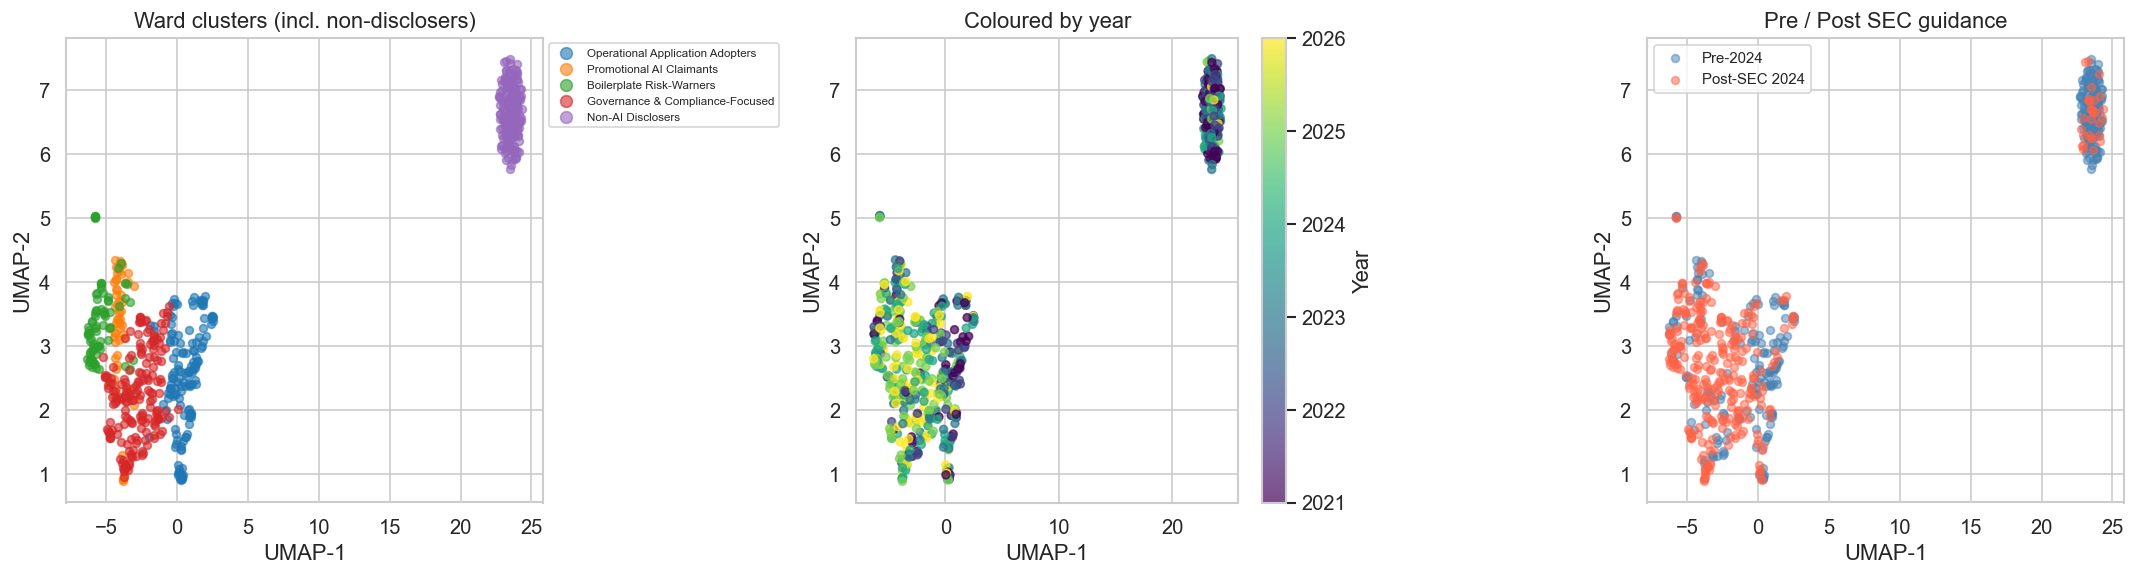

In [10]:
# UMAP runs on X_full (all 658 obs) so non-disclosers are positioned correctly
reducer = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.1, random_state=SEED)
X_umap  = reducer.fit_transform(X_full)
palette = sns.color_palette('tab10', K)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for c in range(K):
    m = ward_labels == c
    ax.scatter(X_umap[m,0], X_umap[m,1], s=22, alpha=0.6,
               label=auto_names[c], color=palette[c])
ax.set_title('Ward clusters (incl. non-disclosers)')
ax.legend(markerscale=1.5, fontsize=7, bbox_to_anchor=(1,1))
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

ax = axes[1]
sc = ax.scatter(X_umap[:,0], X_umap[:,1], c=meta['year'].values, cmap='viridis', s=22, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Year')
ax.set_title('Coloured by year')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

ax = axes[2]
for v, label, color in [(0, 'Pre-2024', 'steelblue'), (1, 'Post-SEC 2024', 'tomato')]:
    m = meta['post_sec_2024'].values == v
    ax.scatter(X_umap[m,0], X_umap[m,1], s=22, alpha=0.5, label=label, color=color)
ax.set_title('Pre / Post SEC guidance')
ax.legend(fontsize=9)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

plt.tight_layout()
plt.show()


## 6. Cluster profiles — read these to name the archetypes

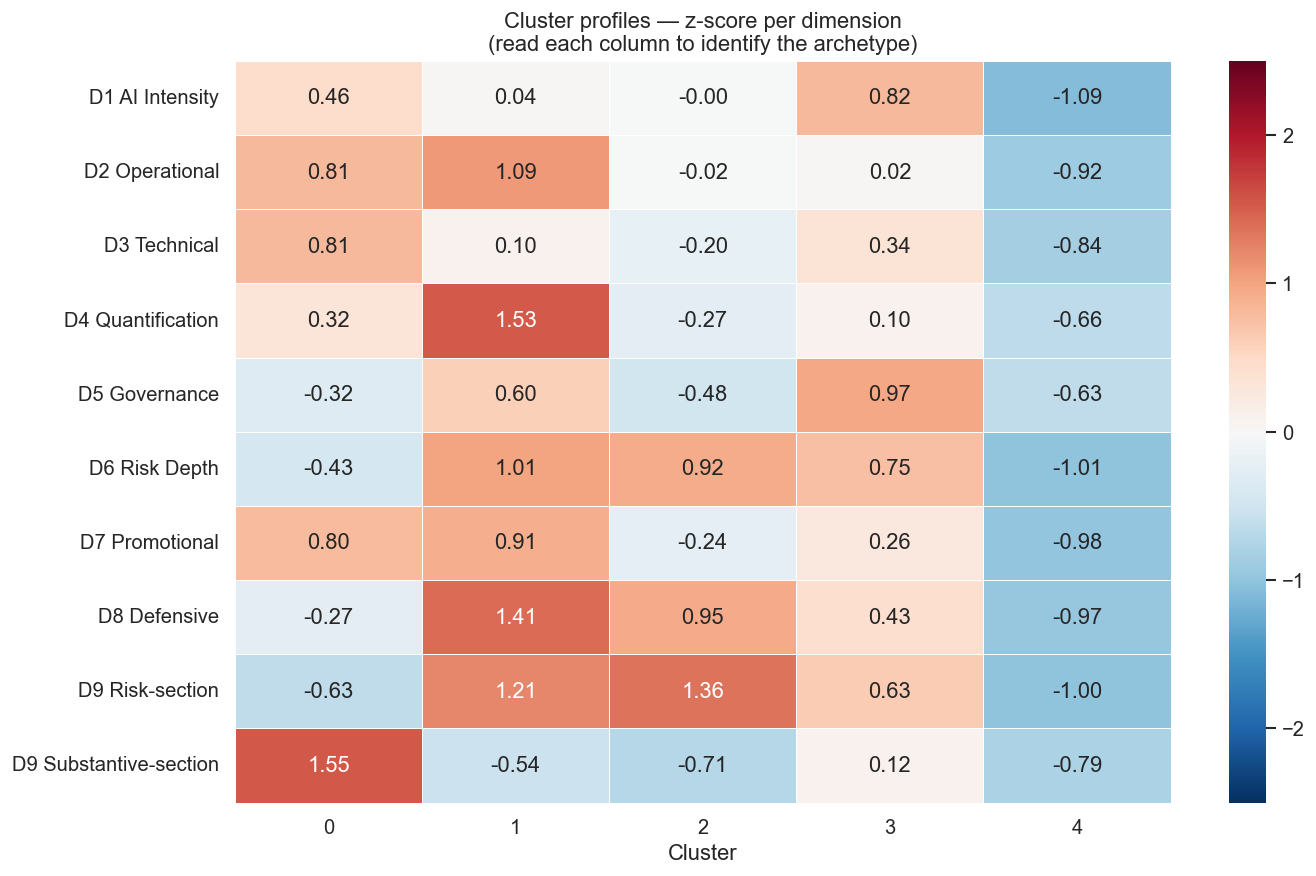

Raw means (0-1 scale):
         D1 AI Intensity  D2 Operational  D3 Technical  D4 Quantification  D5 Governance  D6 Risk Depth  D7 Promotional  D8 Defensive  D9 Risk-section  D9 Substantive-section
cluster                                                                                                                                                                       
0                  0.901           0.093         0.041              0.047          0.010          0.103           0.091         0.093            0.153                   0.424
1                  0.654           0.108         0.024              0.105          0.040          0.357           0.097         0.316            0.910                   0.045
2                  0.629           0.048         0.016              0.018          0.005          0.341           0.038         0.255            0.972                   0.014
3                  1.108           0.051         0.029              0.036          0.052          0.31

In [11]:
profile = dims.copy()
profile['cluster'] = ward_labels

cluster_means = profile.groupby('cluster').mean()
overall_mean  = dims.mean()
overall_std   = dims.std().replace(0, 1)
cluster_z     = (cluster_means - overall_mean) / overall_std
cluster_z_plot = cluster_z.rename(columns=DIM_LABELS)

fig, ax = plt.subplots(figsize=(K * 2.4, len(DIM_LABELS) * 0.6 + 1.5))
sns.heatmap(
    cluster_z_plot.T, annot=True, fmt='.2f', center=0,
    cmap='RdBu_r', linewidths=0.5, ax=ax, vmin=-2.5, vmax=2.5
)
ax.set_xlabel('Cluster')
ax.set_title('Cluster profiles — z-score per dimension\n(read each column to identify the archetype)')
plt.tight_layout()
plt.show()

print('Raw means (0-1 scale):')
print(cluster_means.rename(columns=DIM_LABELS).round(3).to_string())

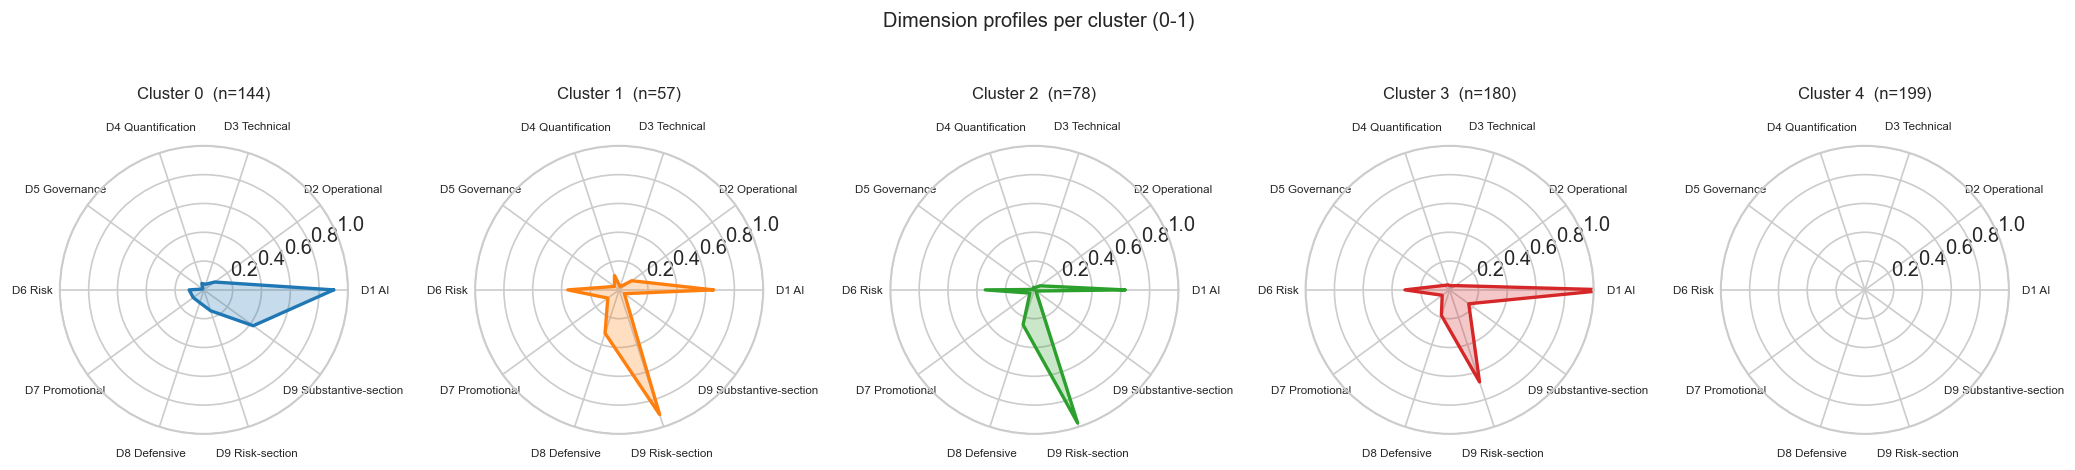

In [12]:
# Radar chart — one polygon per cluster
dim_display = list(DIM_LABELS.values())
N = len(dim_display)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, K, figsize=(K * 3.5, 4), subplot_kw=dict(polar=True))
if K == 1:
    axes = [axes]

for c, ax in zip(range(K), axes):
    values = cluster_means.loc[c, dims.columns].tolist()
    values += values[:1]
    ax.plot(angles, values, color=palette[c], linewidth=2)
    ax.fill(angles, values, color=palette[c], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([d.split()[0] + ' ' + d.split()[1] for d in dim_display], size=7)
    ax.set_ylim(0, 1)
    n_c = int((ward_labels == c).sum())
    ax.set_title(f'Cluster {c}  (n={n_c})', pad=14, fontsize=10)

plt.suptitle('Dimension profiles per cluster (0-1)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 7. Name clusters

Clusters are named automatically from their Ward centroid profiles (previous cell).
**Ward assigns IDs statistically; the rules only label those IDs by reading centroids — no individual observation is classified by rule.**

Naming logic (applied to centroid z-scores):
| Priority | Condition | Label |
|---|---|---|
| 1 | avg AI mentions < 1 | Non-AI Disclosers |
| 2 | D5 Governance leads centroid OR globally highest D5 | Governance & Compliance-Focused |
| 3 | D1 > avg AND D9-substantive > avg AND (D3 or D2) > avg | Full-Stack AI Pioneers |
| 4 | D9-substantive > avg | Operational Application Adopters |
| 5 | fallback | Boilerplate Risk-Warners |

Review the heatmap and radar charts above. If any label looks wrong, override in the cell below.


In [13]:
# Auto-naming produced in d5d294ab cell. Override any mis-labelled cluster here:
CLUSTER_NAMES = auto_names.copy()
# Example overrides (uncomment after reviewing heatmap + radar above):
# CLUSTER_NAMES[1] = 'Boilerplate Risk-Warners'
# CLUSTER_NAMES[2] = 'Promotional AI Claimants'

result['cluster_name']    = result['cluster'].map(CLUSTER_NAMES)
result['cluster_hdbscan'] = hdb_labels        # -2 = non-discloser, -1 = noise
result['cluster_gmm']     = gmm_labels_full   # -1 = non-discloser

print('Final cluster distribution:')
print(result['cluster_name'].value_counts())


Final cluster distribution:
cluster_name
Non-AI Disclosers                   199
Governance & Compliance-Focused     180
Operational Application Adopters    144
Boilerplate Risk-Warners             78
Promotional AI Claimants             57
Name: count, dtype: int64


In [14]:
result

,ticker,year,industry_group,post_sec_2024,post_deepseek,cluster,ai_mentions_count,cluster_name,cluster_hdbscan,cluster_gmm
0,AAPL,2021,Electronic Computers,False,False,4,0,Non-AI Disclosers,-2,-1
1,AAPL,2022,Electronic Computers,False,False,4,0,Non-AI Disclosers,-2,-1
2,AAPL,2023,Electronic Computers,False,False,1,1,Promotional AI Claimants,-1,2
3,AAPL,2024,Electronic Computers,True,False,1,2,Promotional AI Claimants,-1,2
4,AAPL,2025,Electronic Computers,True,True,3,5,Governance & Compliance-Focused,-1,2
...,...,...,...,...,...,...,...,...,...,...
653,ZS,2021,Services-Computer Programming Services,False,False,0,1,Operational Application Adopters,-1,1
654,ZS,2022,Services-Computer Programming Services,False,False,4,0,Non-AI Disclosers,-2,-1
655,ZS,2023,Services-Computer Programming Services,False,False,0,6,Operational Application Adopters,-1,0
656,ZS,2024,Services-Computer Programming Services,True,False,3,13,Governance & Compliance-Focused,1,0


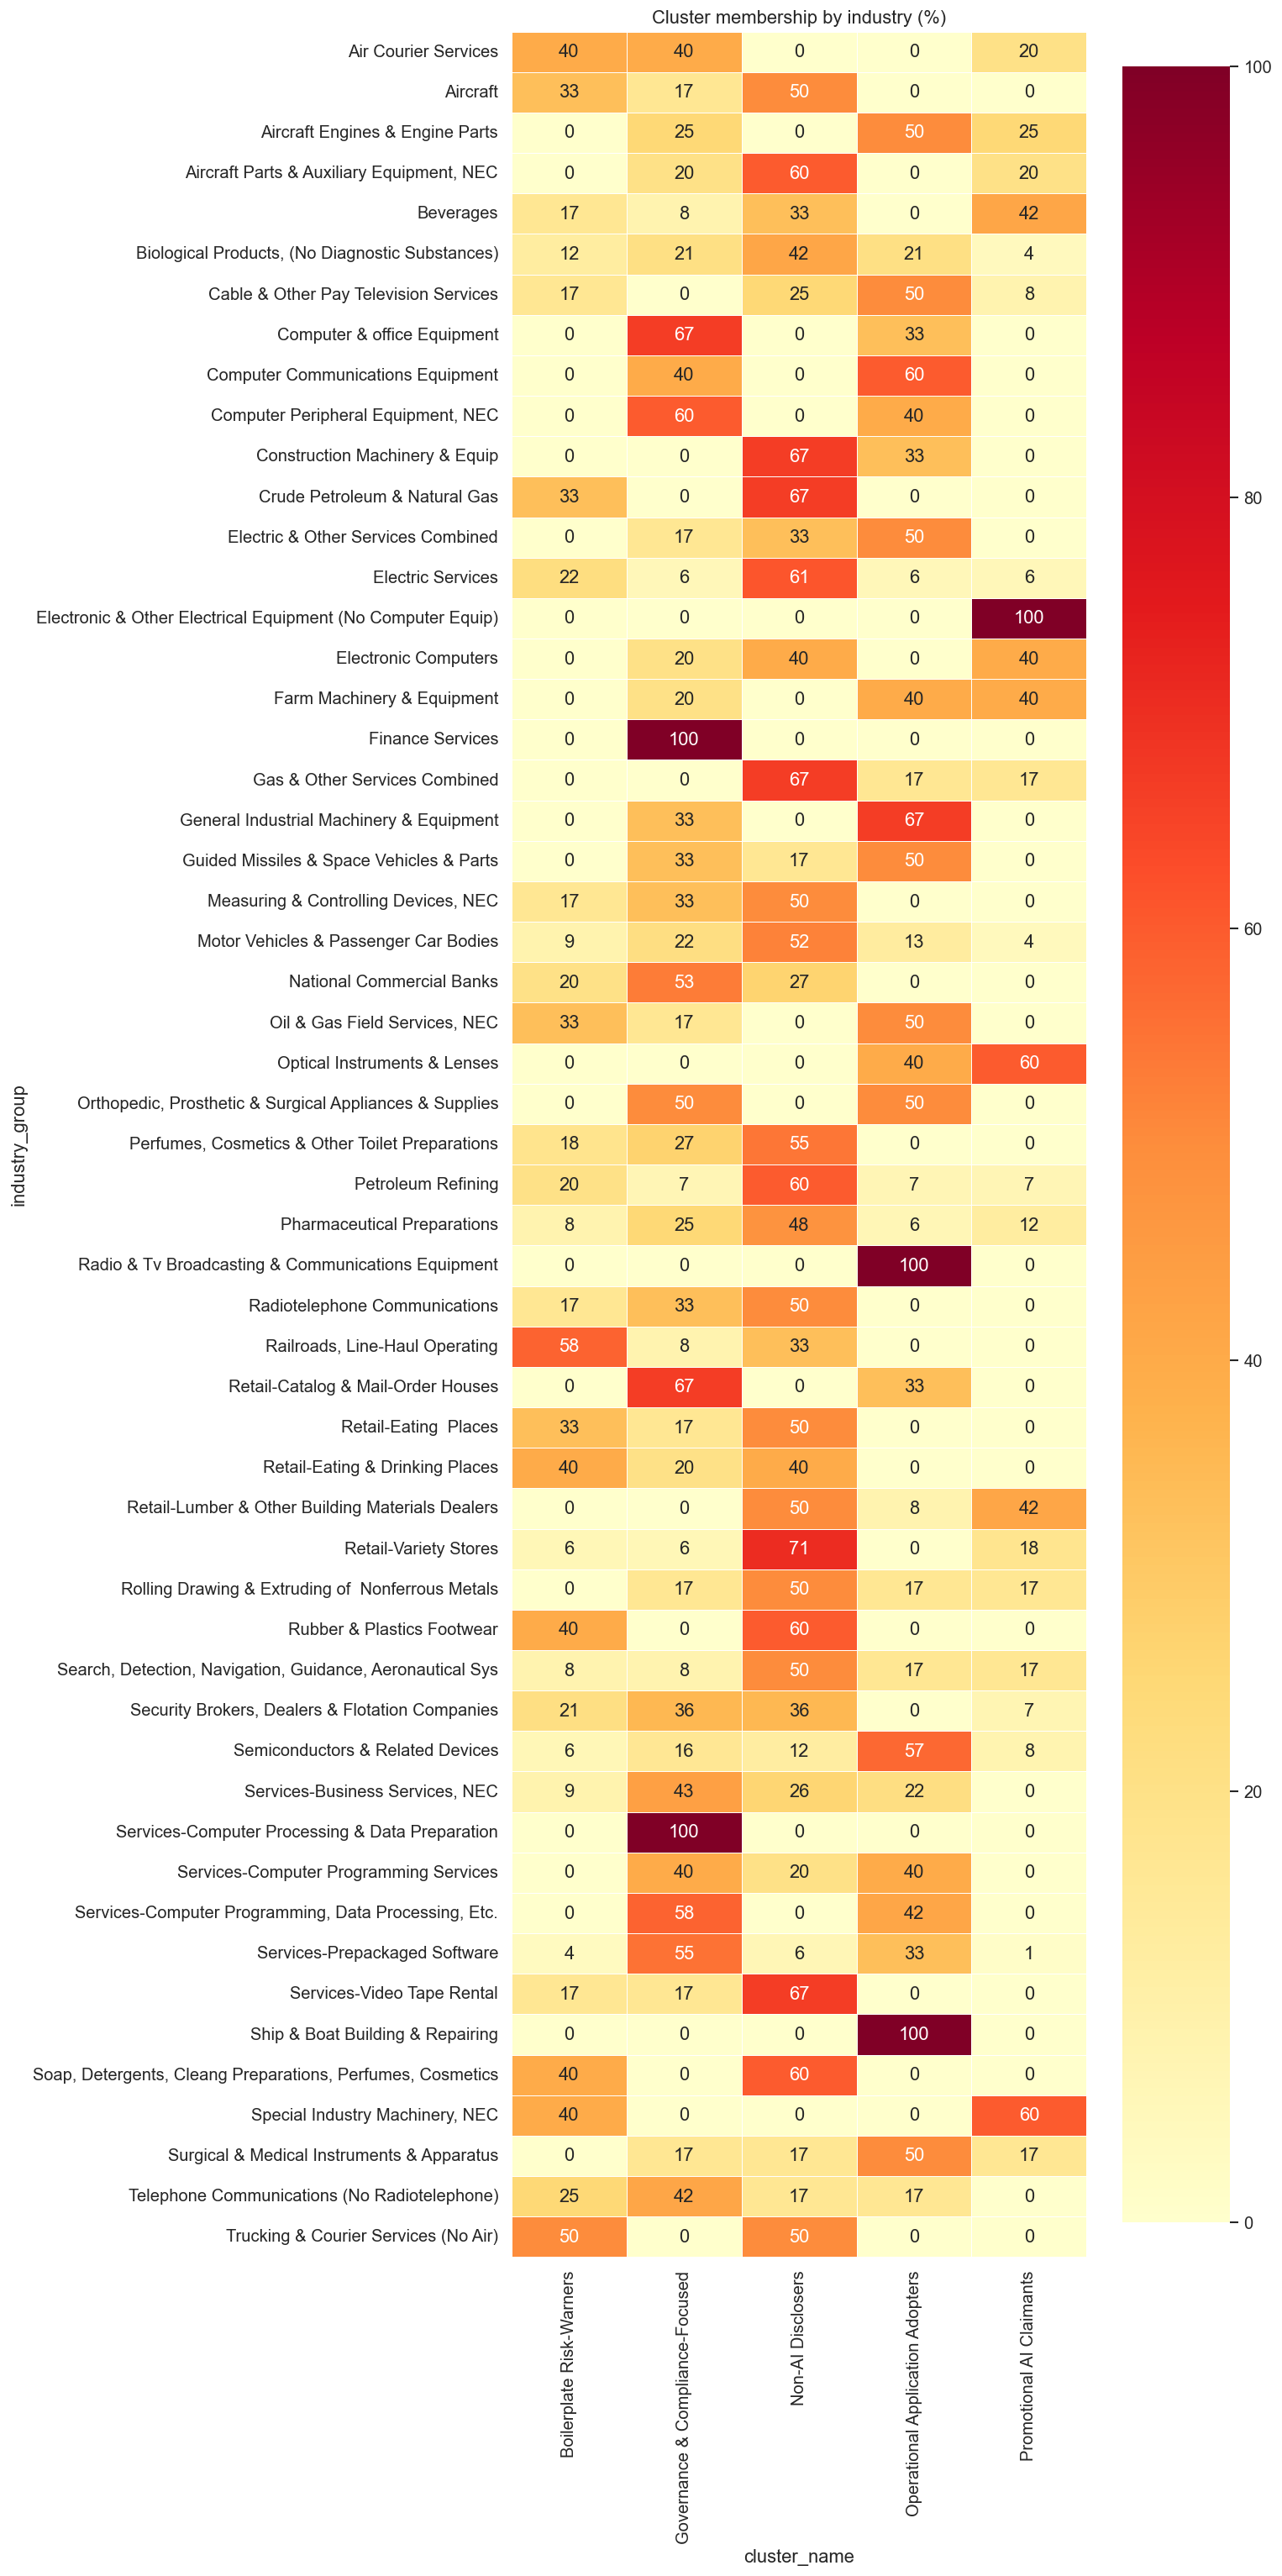

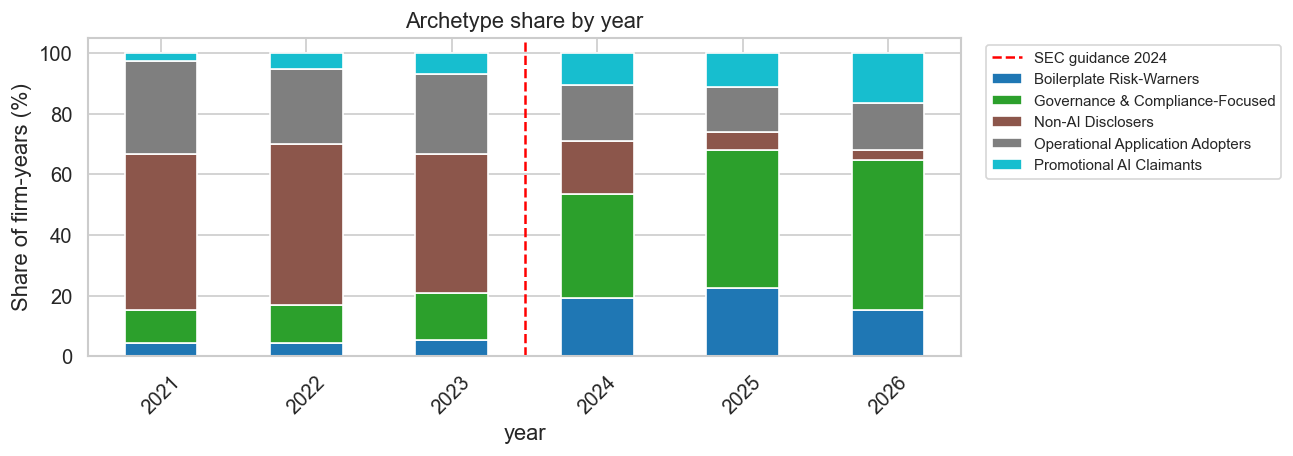

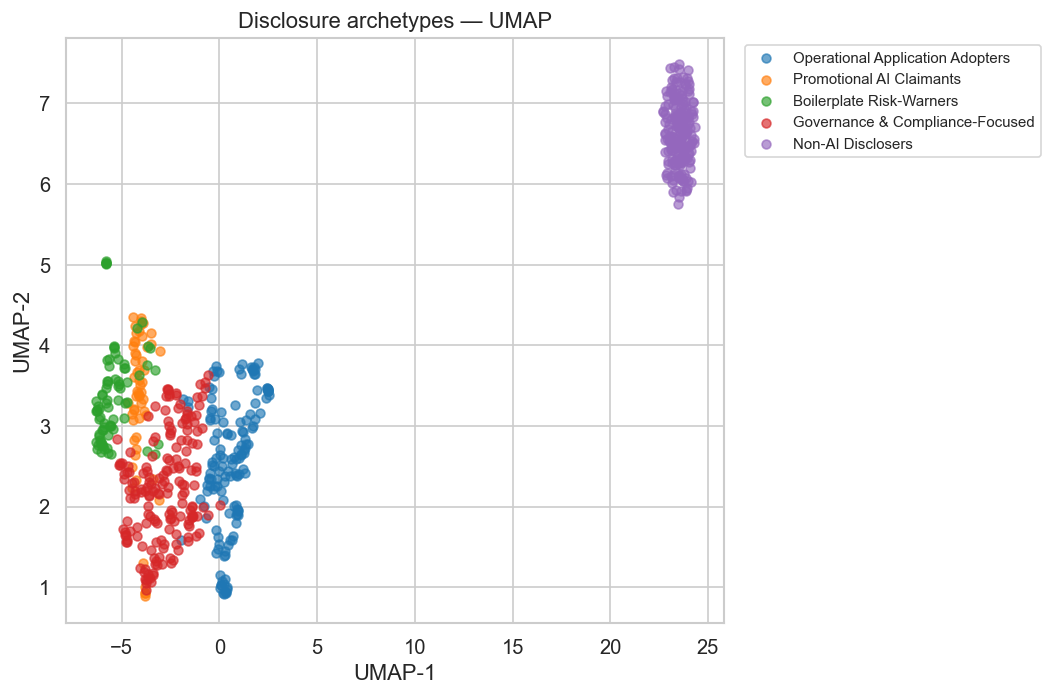

In [15]:
ct = pd.crosstab(result['industry_group'], result['cluster_name'], normalize='index') * 100
fig, ax = plt.subplots(figsize=(K * 2.5, max(4, len(ct) * 0.45 + 1)))
sns.heatmap(ct, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.3, ax=ax)
ax.set_title('Cluster membership by industry (%)')
plt.tight_layout()
plt.show()

yr_ct = pd.crosstab(result['year'], result['cluster_name'], normalize='index') * 100
yr_ct.plot(kind='bar', stacked=True, figsize=(11, 4), colormap='tab10')
try:
    plt.axvline(list(yr_ct.index).index(2024) - 0.5, color='red', linestyle='--', linewidth=1.5, label='SEC guidance 2024')
except ValueError:
    pass
plt.ylabel('Share of firm-years (%)')
plt.title('Archetype share by year')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(K):
    m = ward_labels == c
    ax.scatter(X_umap[m,0], X_umap[m,1], s=28, alpha=0.65,
               label=CLUSTER_NAMES[c], color=palette[c])
ax.set_title('Disclosure archetypes — UMAP')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Save

In [16]:
out = result.copy()
out = out.join(dims.rename(columns=DIM_LABELS))
out['umap1'] = X_umap[:, 0]
out['umap2'] = X_umap[:, 1]

out_path = DATA / 'processed/clusters/firm_year_clusters.parquet'
out_path.parent.mkdir(parents=True, exist_ok=True)
out.to_parquet(out_path, index=False)
print(f'Saved {len(out)} rows to {out_path}')
out.head()

Saved 658 rows to ../data/processed/clusters/firm_year_clusters.parquet


,ticker,year,industry_group,post_sec_2024,post_deepseek,cluster,ai_mentions_count,cluster_name,cluster_hdbscan,cluster_gmm,...,D3 Technical,D4 Quantification,D5 Governance,D6 Risk Depth,D7 Promotional,D8 Defensive,D9 Risk-section,D9 Substantive-section,umap1,umap2
0,AAPL,2021,Electronic Computers,False,False,4,0,Non-AI Disclosers,-2,-1,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,23.763029,6.616935
1,AAPL,2022,Electronic Computers,False,False,4,0,Non-AI Disclosers,-2,-1,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,23.594872,6.556933
2,AAPL,2023,Electronic Computers,False,False,1,1,Promotional AI Claimants,-1,2,...,0.03125,0.000000,0.071429,0.529412,0.037037,0.230769,1.0,0.0,-4.443425,3.149373
3,AAPL,2024,Electronic Computers,True,False,1,2,Promotional AI Claimants,-1,2,...,0.03125,0.000000,0.035714,0.470588,0.037037,0.153846,1.0,0.0,-4.661212,3.278316
4,AAPL,2025,Electronic Computers,True,True,3,5,Governance & Compliance-Focused,-1,2,...,0.03125,0.018182,0.042857,0.364706,0.022222,0.153846,1.0,0.0,-4.697724,2.502552
